#**Extração dos Dados**

In [2]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)

dados = response.json()

df = pd.json_normalize(dados)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#**Limpeza e Tratamento dos Dados**

In [4]:
df = df.drop_duplicates()

df = df.replace(" ", pd.NA)

df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

df = df.dropna(subset=["account.Charges.Total"])

df.columns = df.columns.str.replace(".", "_")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [5]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


#**Análise Exploratória Inicial**

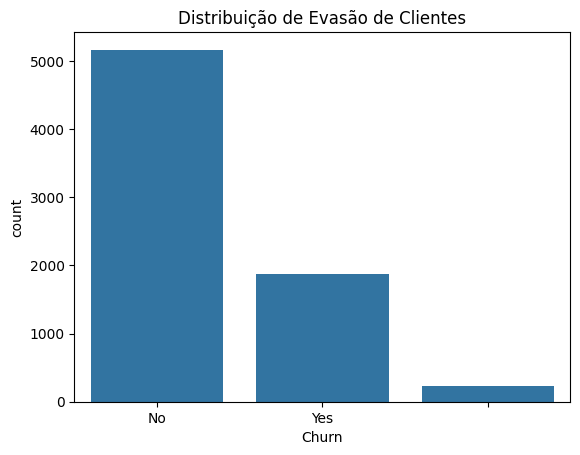

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(x="Churn", data=df)

plt.title("Distribuição de Evasão de Clientes")

plt.show()

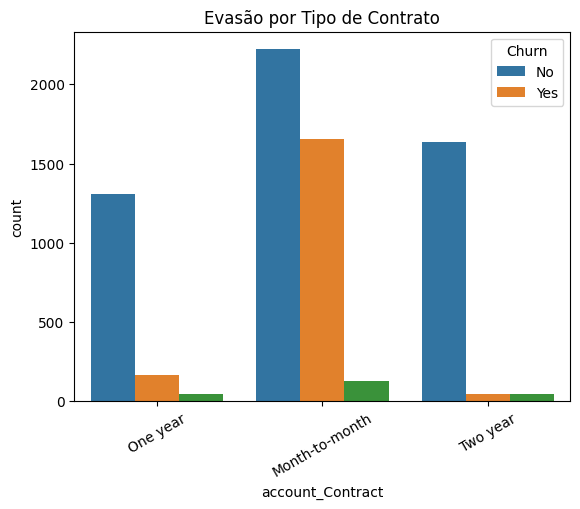

In [7]:
plt.figure()

sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.title("Evasão por Tipo de Contrato")

plt.xticks(rotation=30)

plt.show()

#**Preparação para Machine Learning**

In [15]:
print("Churn value counts before mapping:")
print(df["Churn"].value_counts(dropna=False))

df["Churn"] = df["Churn"].astype(str).str.strip().map({"Yes":1,"No":0})

print("Churn value counts after mapping:")
print(df["Churn"].value_counts(dropna=False))

df_modelo = pd.get_dummies(df, drop_first=True)

df_modelo.head()

Churn value counts before mapping:
Churn
NaN    7256
Name: count, dtype: int64
Churn value counts after mapping:
Churn
NaN    7256
Name: count, dtype: int64


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,NaN,0,9,65.6,593.30,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,NaN,0,9,59.9,542.40,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,NaN,0,4,73.9,280.85,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,NaN,1,13,98.0,1237.85,False,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,NaN,1,3,83.9,267.40,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [30]:
X = df_modelo.drop("Churn", axis=1)
y = df_modelo["Churn"]

# Drop rows with NaN values in the target variable 'y' and corresponding rows in 'X'
valid_indices = ~y.isnull()
X = X[valid_indices]
y = y[valid_indices]

print("df_modelo['Churn'] value counts after get_dummies:")
print(df_modelo["Churn"].value_counts(dropna=False))
print("y value counts after NaN removal and assignment:")
print(y.value_counts(dropna=False))

df_modelo['Churn'] value counts after get_dummies:
Churn
0.0    5163
1.0    1869
NaN     224
Name: count, dtype: int64
y value counts after NaN removal and assignment:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64


#**Separação de Dados (Treino e Teste)**

In [32]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("y_treino value counts after split:")
print(y_treino.value_counts(dropna=False))
print("y_teste value counts after split:")
print(y_teste.value_counts(dropna=False))

y_treino value counts after split:
Churn
0.0    3609
1.0    1313
Name: count, dtype: int64
y_teste value counts after split:
Churn
0.0    1554
1.0     556
Name: count, dtype: int64


In [18]:
print(X_treino.shape)
print(X_teste.shape)

(5079, 7285)
(2177, 7285)


#**Criação dos Modelos Preditivos**

In [31]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=2000)

# Fit the model using the cleaned training data (NaNs removed earlier)
modelo_logistico.fit(X_treino, y_treino)

pred_log = modelo_logistico.predict(X_teste)

ValueError: Input y contains NaN.

#**Extração dos Dados**

In [33]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json"

response = requests.get(url)

dados = response.json()

df = pd.json_normalize(dados)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

#**Limpeza e Tratamento dos Dados**

In [35]:
df = df.drop_duplicates()

df = df.replace(" ", pd.NA)

df["account.Charges.Total"] = pd.to_numeric(df["account.Charges.Total"], errors="coerce")

df = df.dropna(subset=["account.Charges.Total"])

df.columns = df.columns.str.replace(".", "_")

df.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40


In [36]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


#**Análise Exploratória Inicial**

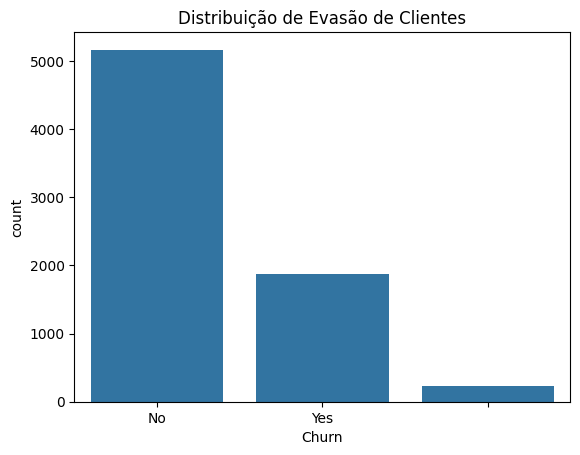

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()

sns.countplot(x="Churn", data=df)

plt.title("Distribuição de Evasão de Clientes")

plt.show()

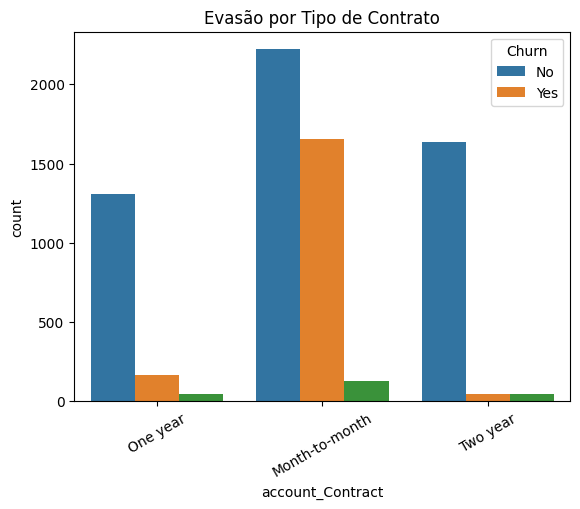

In [38]:
plt.figure()

sns.countplot(x="account_Contract", hue="Churn", data=df)

plt.title("Evasão por Tipo de Contrato")

plt.xticks(rotation=30)

plt.show()

#**Preparação para Machine Learning**

In [39]:
print("Churn value counts before mapping:")
print(df["Churn"].value_counts(dropna=False))

df["Churn"] = df["Churn"].astype(str).str.strip().map({"Yes":1,"No":0})

print("Churn value counts after mapping:")
print(df["Churn"].value_counts(dropna=False))

df_modelo = pd.get_dummies(df, drop_first=True)

df_modelo.head()

Churn value counts before mapping:
Churn
No     5163
Yes    1869
        224
Name: count, dtype: int64
Churn value counts after mapping:
Churn
0.0    5163
1.0    1869
NaN     224
Name: count, dtype: int64


,Churn,customer_SeniorCitizen,customer_tenure,account_Charges_Monthly,account_Charges_Total,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,...,internet_StreamingTV_No internet service,internet_StreamingTV_Yes,internet_StreamingMovies_No internet service,internet_StreamingMovies_Yes,account_Contract_One year,account_Contract_Two year,account_PaperlessBilling_Yes,account_PaymentMethod_Credit card (automatic),account_PaymentMethod_Electronic check,account_PaymentMethod_Mailed check
0,0.0,0,9,65.6,593.30,False,False,False,False,False,...,False,True,False,False,True,False,True,False,False,True
1,0.0,0,9,59.9,542.40,True,False,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,1.0,0,4,73.9,280.85,False,True,False,False,False,...,False,False,False,False,False,False,True,False,True,False
3,1.0,1,13,98.0,1237.85,False,False,True,False,False,...,False,True,False,True,False,False,True,False,True,False
4,1.0,1,3,83.9,267.40,False,False,False,True,False,...,False,True,False,False,False,False,True,False,False,True


In [40]:
X = df_modelo.drop("Churn", axis=1)
y = df_modelo["Churn"]

# Drop rows with NaN values in the target variable 'y' and corresponding rows in 'X'
valid_indices = ~y.isnull()
X = X[valid_indices]
y = y[valid_indices]

print("df_modelo['Churn'] value counts after get_dummies:")
print(df_modelo["Churn"].value_counts(dropna=False))
print("y value counts after NaN removal and assignment:")
print(y.value_counts(dropna=False))

df_modelo['Churn'] value counts after get_dummies:
Churn
0.0    5163
1.0    1869
NaN     224
Name: count, dtype: int64
y value counts after NaN removal and assignment:
Churn
0.0    5163
1.0    1869
Name: count, dtype: int64


#**Separação de Dados (Treino e Teste)**

In [41]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

print("y_treino value counts after split:")
print(y_treino.value_counts(dropna=False))
print("y_teste value counts after split:")
print(y_teste.value_counts(dropna=False))

y_treino value counts after split:
Churn
0.0    3609
1.0    1313
Name: count, dtype: int64
y_teste value counts after split:
Churn
0.0    1554
1.0     556
Name: count, dtype: int64


In [42]:
print(X_treino.shape)
print(X_teste.shape)

(4922, 7285)
(2110, 7285)


#**Criação dos Modelos Preditivos**

In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

modelo_logistico = LogisticRegression(max_iter=5000)

# Scale the features
scaler = StandardScaler()
X_treino_scaled = scaler.fit_transform(X_treino)
X_teste_scaled = scaler.transform(X_teste)

# Fit the model using the scaled training data
modelo_logistico.fit(X_treino_scaled, y_treino)

pred_log = modelo_logistico.predict(X_teste_scaled)

In [46]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(random_state=42)

modelo_rf.fit(X_treino, y_treino)

pred_rf = modelo_rf.predict(X_teste)

#**Avaliação dos Modelos**

In [47]:
from sklearn.metrics import accuracy_score, classification_report

print("Acurácia Regressão Logística")

print(accuracy_score(y_teste, pred_log))

print(classification_report(y_teste, pred_log))

Acurácia Regressão Logística
0.7838862559241706
              precision    recall  f1-score   support

         0.0       0.80      0.95      0.87      1554
         1.0       0.69      0.33      0.44       556

    accuracy                           0.78      2110
   macro avg       0.74      0.64      0.65      2110
weighted avg       0.77      0.78      0.75      2110



In [48]:
print("Acurácia Random Forest")

print(accuracy_score(y_teste, pred_rf))

print(classification_report(y_teste, pred_rf))

Acurácia Random Forest
0.7886255924170616
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1554
         1.0       0.63      0.47      0.54       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



#**Matriz de Confusão**

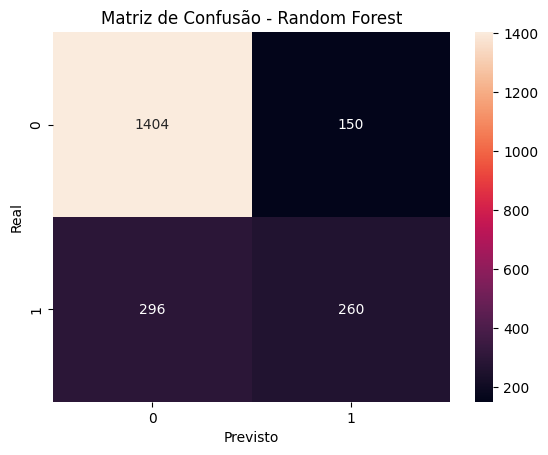

In [49]:
from sklearn.metrics import confusion_matrix

plt.figure()

sns.heatmap(confusion_matrix(y_teste, pred_rf), annot=True, fmt="d")

plt.title("Matriz de Confusão - Random Forest")

plt.xlabel("Previsto")

plt.ylabel("Real")

plt.show()

In [50]:
import pandas as pd

importancias = modelo_rf.feature_importances_

variaveis = X.columns

df_importancia = pd.DataFrame({
    "variavel":variaveis,
    "importancia":importancias
})

df_importancia = df_importancia.sort_values(by="importancia", ascending=False)

df_importancia.head(10)


,variavel,importancia
1,customer_tenure,0.102747
3,account_Charges_Total,0.102122
2,account_Charges_Monthly,0.079927
7283,account_PaymentMethod_Electronic check,0.028766
7265,internet_InternetService_Fiber optic,0.027503
7280,account_Contract_Two year,0.022597
7268,internet_OnlineSecurity_Yes,0.020272
7274,internet_TechSupport_Yes,0.020253
7281,account_PaperlessBilling_Yes,0.017016
7279,account_Contract_One year,0.016517


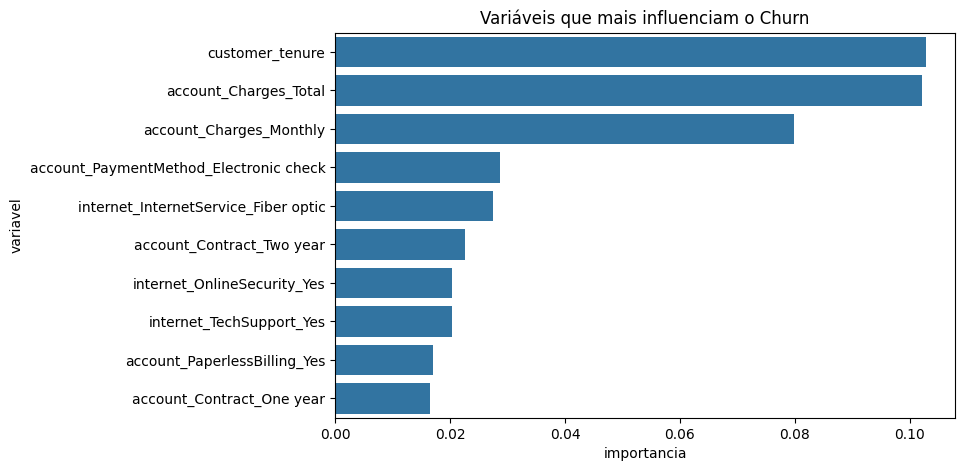

In [51]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="importancia",
    y="variavel",
    data=df_importancia.head(10)
)

plt.title("Variáveis que mais influenciam o Churn")

plt.show()

#**Conclusão**

A partir da análise e dos modelos preditivos, foi possível identificar padrões associados à evasão de clientes.

Alguns fatores com maior influência incluem:

* tipo de contrato

* valor mensal cobrado

* tempo de permanência do cliente

* serviços adicionais contratados


Os modelos desenvolvidos permitem prever clientes com maior risco de churn, possibilitando que a empresa desenvolva estratégias de retenção mais eficazes.

Com base nesses resultados, a empresa pode:

* oferecer incentivos para contratos de longo prazo

* monitorar clientes com alto risco de cancelamento

* desenvolver campanhas de retenção direcionadas

Essas estratégias podem contribuir para reduzir a evasão e melhorar a fidelização dos clientes.